In [1]:
%matplotlib ipympl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
import make_pes as mpes

In [3]:
#check holes from the fit 6D_extend_0
p, orders = mpes.get_coeffs_orders('6D_extend_0.res')
nonlin_p = mpes.get_non_linear_p('6D_extend_0.res')
pes = mpes.get_pes_v4(p, nonlin_p, orders)

In [4]:
#coordinate values from largest residual
coord_val_constants = [1.46461729, 1.61099546, 0.96380778, 110.46377558, 115.67092131, 0.000]
#coord_val_constants = [1.503757, 1.364142, 0.96380778, 110.46377558, 139.6519, 148.0226]
#coord_val_constants = [1.46461729, 1.61099546, 1.6, 110.46377558, 139.6519, 148.0226]

#create varying tau and a_hop grid
tau_grid = np.linspace(-60, 260, 50)
apoh_grid = np.linspace(70, 180, 50)
apoh_tau_mesh = np.meshgrid(apoh_grid, tau_grid)
apoh_mesh = apoh_tau_mesh[0]
tau_mesh = apoh_tau_mesh[1]

#create 6D geometries with a varying 2D mesh
geometry_apoh_tau = np.zeros((len(apoh_grid)*len(tau_grid), 
                             6) )
#flattened for pes compute input
geometry_apoh_tau[:, 4] = apoh_mesh.flatten() #insert varying 2D grid
geometry_apoh_tau[:, 5] = tau_mesh.flatten()

for j in [0,1,2,3]:
    #insert fixed coordinate values
    geometry_apoh_tau[:, j] = coord_val_constants[j]

#compute pes values, reshape into 2D grid
pes_vals_apoh_tau = pes(geometry_apoh_tau)
pes_vals_apoh_tau = np.reshape(pes_vals_apoh_tau, 
                        (len(tau_grid), len(apoh_grid)) 
                       )

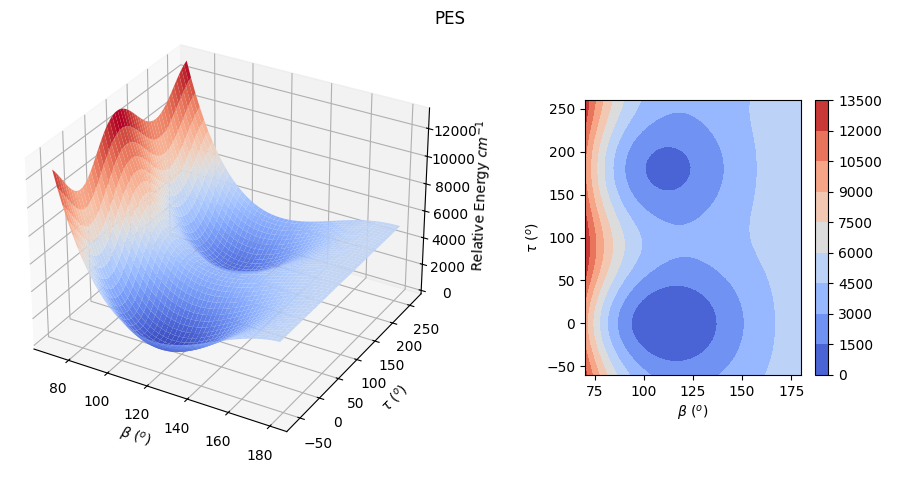

In [5]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('PES')
ax_3d = fig.add_axes([-0.1, 0.08, 0.7, 0.9], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    apoh_mesh, tau_mesh, pes_vals_apoh_tau,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
#ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$\beta$ ($^{o}$)')
ax_3d.set_ylabel(r'$\tau$ ($^{o}$)') 
ax_3d.set_zlabel(r'Relative Energy $cm^{-1}$');
ax_3d.axis('tight');

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.3, 0.55])  
contour = ax_contour.contourf(
    apoh_mesh, tau_mesh, pes_vals_apoh_tau,
    levels=10,
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$\beta$ ($^{o}$)')
ax_contour.set_ylabel(r'$\tau$ ($^{o}$)') 

plt.colorbar(contour, ax=ax_contour)
plt.show()

In [6]:
test_minima = pes(np.reshape(np.array(coord_val_constants), (1,6)))
#test_minima_2 = pes(np.reshape(np.array([1.468331, 1.604292, 0.967982, 110.7285, 113.0548, 0.0000]),
#                              (1,6))
#                   )
test_minima_2 = pes(np.reshape(np.array([1.468331, 1.604292, 0.967982, 110.7285, 115.67092131, 0.0000]),
                              (1,6))
                   )
#coord_val_constants = [1.46461729, 1.61099546, 0.96380778, 110.46377558, 115.67092131, 0.000]
print(test_minima)
print(test_minima_2)

[38.42071776]
[21.66006965]
